# E-Commerce Sales & Customer Analytics - Python EDA

This notebook performs exploratory data analysis for the e-commerce sales project. It covers data loading, cleaning, feature engineering, KPI calculation, visualization, and business insights.

## 1. Import Libraries

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 50)

## 2. Load Dataset

In [18]:
root = Path.cwd()
data_path = root / "Data & Resources" / "ECOMM DATA.xlsx"

if not data_path.exists():
    root = root.parent
    data_path = root / "Data & Resources" / "ECOMM DATA.xlsx"

orders = pd.read_excel(data_path, sheet_name="Orders")
returns = pd.read_excel(data_path, sheet_name="Returns")
people = pd.read_excel(data_path, sheet_name="People")

orders.shape, returns.shape, people.shape

/Users/rajeshreddyatthunuri/Desktop/Data_Projects/E-Commerce-Data-Analysis-main/.venv/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


((51290, 24), (1173, 3), (13, 2))

## 3. Data Cleaning

In [19]:
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace("-", "_", regex=False)
        .str.replace(" ", "_", regex=False)
    )
    return df


orders = clean_columns(orders)
returns = clean_columns(returns)
people = clean_columns(people)

text_columns = ["category", "sub_category", "segment", "market", "region", "ship_mode"]
for column in text_columns:
    orders[column] = orders[column].astype(str).str.strip().str.title()

orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["ship_date"] = pd.to_datetime(orders["ship_date"])

null_summary = orders.isna().sum().sort_values(ascending=False)
duplicate_rows = orders.duplicated().sum()
duplicate_order_products = orders.duplicated(subset=["order_id", "product_id", "product_name"]).sum()
data_types = orders.dtypes

print("Top null counts:")
display(null_summary.head(10))
print(f"Duplicate full rows: {duplicate_rows:,}")
print(f"Duplicate order/product rows: {duplicate_order_products:,}")
display(data_types)

Top null counts:


postal_code      41296
order_id             0
profit               0
shipping_cost        0
discount             0
quantity             0
sales                0
product_name         0
sub_category         0
category             0
dtype: int64

Duplicate full rows: 0
Duplicate order/product rows: 36


row_id                     int64
order_id                     str
order_date        datetime64[us]
ship_date         datetime64[us]
ship_mode                    str
customer_id                  str
customer_name                str
segment                      str
city                         str
state                        str
country                      str
market                       str
postal_code              float64
region                       str
product_id                   str
category                     str
sub_category                 str
product_name                 str
sales                    float64
quantity                   int64
discount                 float64
shipping_cost            float64
profit                   float64
order_priority               str
dtype: object

### Outlier and Category Validation

Outliers are flagged using the IQR method. They are reviewed rather than automatically removed because unusually high sales or shipping values may be valid business transactions.

In [20]:
numeric_columns = ["sales", "quantity", "discount", "shipping_cost", "profit"]
outlier_summary = []

for column in numeric_columns:
    q1 = orders[column].quantile(0.25)
    q3 = orders[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = orders[(orders[column] < lower) | (orders[column] > upper)]
    outlier_summary.append({
        "column": column,
        "lower_bound": lower,
        "upper_bound": upper,
        "potential_outliers": len(outliers)
    })

display(pd.DataFrame(outlier_summary))
orders[["category", "segment", "market", "ship_mode"]].nunique()

,column,lower_bound,upper_bound,potential_outliers
0,sales,-299.683238,581.495063,5655
1,quantity,-2.500000,9.500000,877
2,discount,-0.300000,0.500000,4172
3,shipping_cost,-30.150000,57.210000,5909
4,profit,-55.215000,92.025000,9755


category     3
segment      3
market       7
ship_mode    4
dtype: int64

## 4. Feature Engineering

New fields are created for trend analysis, shipping performance, return tracking, discount bands, and profitability analysis.

In [21]:
orders["order_year"] = orders["order_date"].dt.year
orders["order_month"] = orders["order_date"].dt.month
orders["order_month_name"] = orders["order_date"].dt.strftime("%b")
orders["year_month"] = orders["order_date"].dt.to_period("M").astype(str)
orders["shipping_delay"] = (orders["ship_date"] - orders["order_date"]).dt.days
orders["profit_margin"] = orders["profit"] / orders["sales"]
orders["customer_segment"] = orders["segment"]
orders["sales_bucket"] = pd.cut(
    orders["sales"],
    bins=[-0.01, 100, 500, 1000, float("inf")],
    labels=["Low", "Medium", "High", "Premium"]
)

returned_orders = set(returns["order_id"].dropna())
orders["is_returned"] = orders["order_id"].isin(returned_orders)

orders["discount_band"] = pd.cut(
    orders["discount"],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 1],
    labels=["No Discount", "0-10%", "10-20%", "20-30%", "30%+"]
)

orders.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,country,market,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,shipping_cost,profit,order_priority,order_year,order_month,order_month_name,year_month,shipping_delay,profit_margin,customer_segment,sales_bucket,is_returned,discount_band
0,26341,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,Us,10024.0,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,933.57,762.1845,Critical,2012,7,Jul,2012-07,0,0.330000,Consumer,Premium,False,No Discount
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,Apac,NaN,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,923.63,-288.7650,Critical,2013,2,Feb,2013-02,2,-0.077847,Corporate,Premium,True,0-10%
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,Apac,NaN,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,915.49,919.9710,Medium,2013,10,Oct,2013-10,1,0.177766,Consumer,Premium,False,0-10%
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,Eu,NaN,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,910.16,-96.5400,Medium,2013,1,Jan,2013-01,2,-0.033376,Home Office,Premium,False,0-10%
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Africa,NaN,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,903.04,311.5200,Critical,2013,11,Nov,2013-11,1,0.109963,Consumer,Premium,False,No Discount


## 5. KPI Calculations

In [22]:
total_sales = orders["sales"].sum()
total_profit = orders["profit"].sum()
total_orders = orders["order_id"].nunique()
customer_order_counts = orders.groupby("customer_id")["order_id"].nunique()

kpis = pd.Series({
    "Total Sales": total_sales,
    "Total Profit": total_profit,
    "Total Orders": total_orders,
    "Average Order Value": total_sales / total_orders,
    "Profit Margin %": total_profit / total_sales,
    "Top Region": orders.groupby("region")["sales"].sum().idxmax(),
    "Top Category": orders.groupby("category")["sales"].sum().idxmax(),
    "Repeat Customer Rate": (customer_order_counts > 1).mean()
})

kpis

Total Sales             12642501.90988
Total Profit             1467457.29128
Total Orders                     25035
Average Order Value         504.993086
Profit Margin %               0.116073
Top Region                     Central
Top Category                Technology
Repeat Customer Rate          0.993711
dtype: object

## 6. Sales Trend

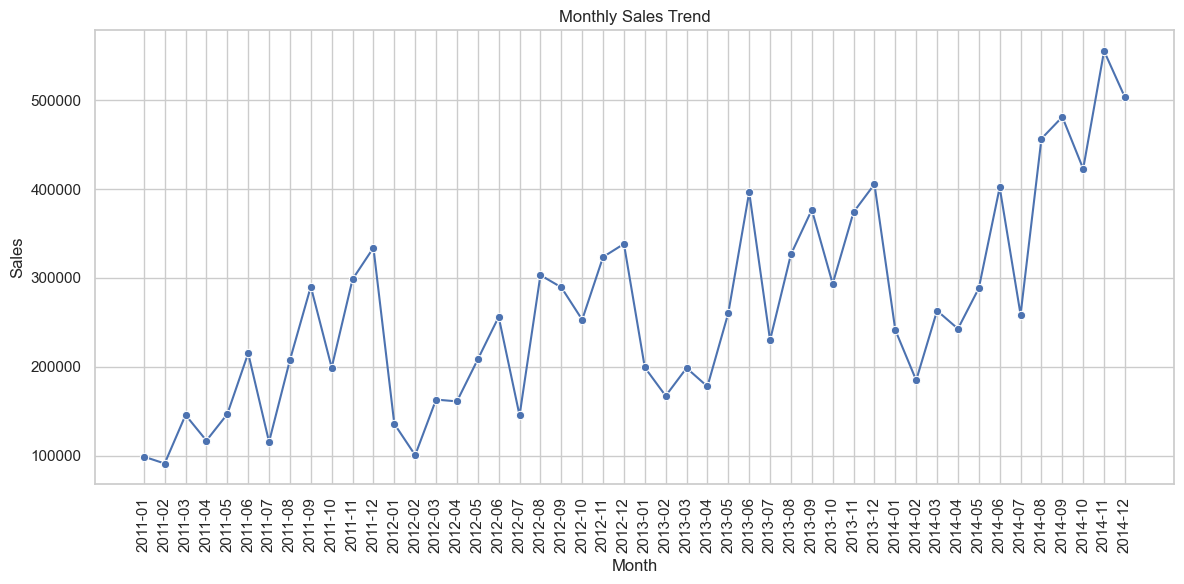

In [23]:
monthly_sales = (
    orders.groupby("year_month", as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"))
)

sns.lineplot(data=monthly_sales, x="year_month", y="sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Insight:** Monthly sales show how demand changes over time and help identify growth patterns, seasonality, and periods that may need deeper investigation.

## 7. Category and Sub-Category Performance

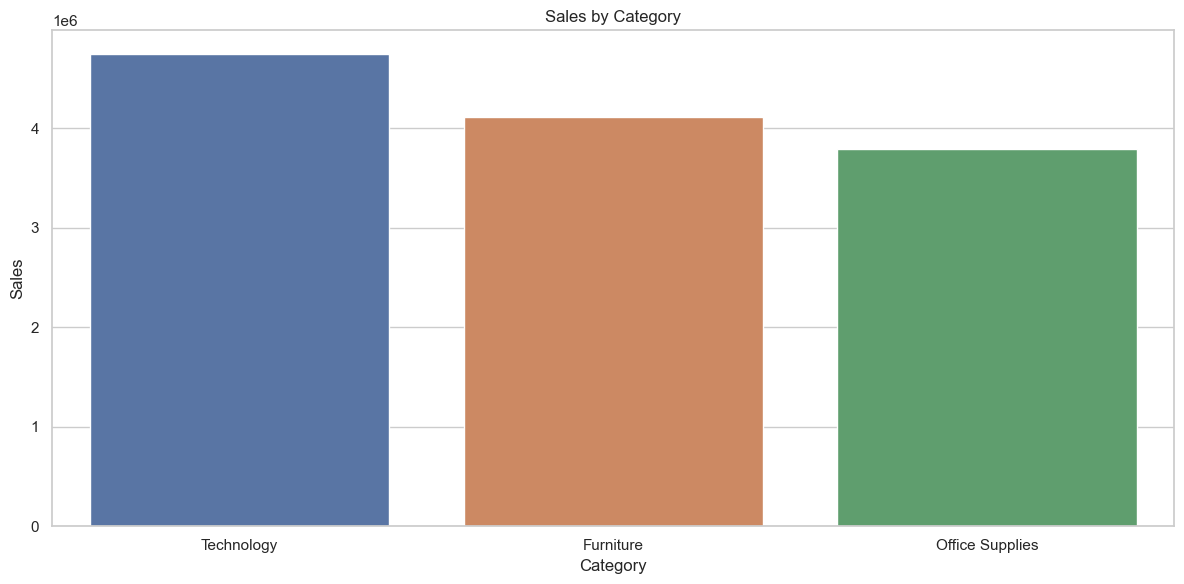

,category,sales,profit,quantity
2,Technology,4.744557e+06,663778.73318,35176
0,Furniture,4.110874e+06,285204.72380,34954
1,Office Supplies,3.787070e+06,518473.83430,108182


In [24]:
category_perf = (
    orders.groupby("category", as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), quantity=("quantity", "sum"))
    .sort_values("sales", ascending=False)
)

sns.barplot(data=category_perf, x="category", y="sales", hue="category", legend=False)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

category_perf

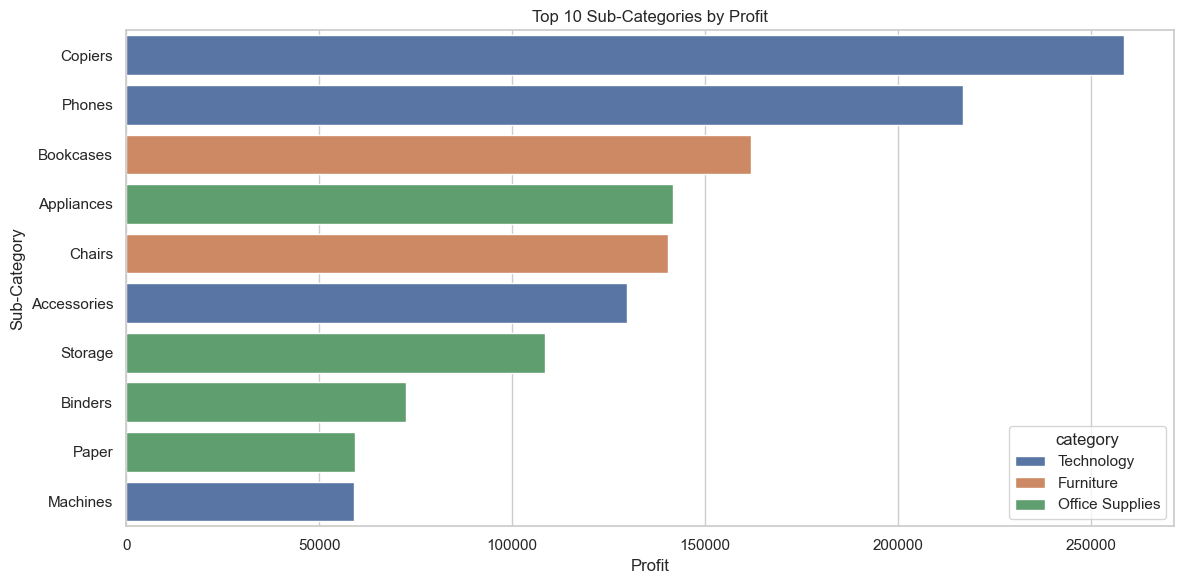

,category,sub_category,sales,profit
14,Technology,Copiers,1.509436e+06,258567.54818
16,Technology,Phones,1.706824e+06,216717.00580
0,Furniture,Bookcases,1.466572e+06,161924.41950
4,Office Supplies,Appliances,1.011064e+06,141680.58940
1,Furniture,Chairs,1.501682e+06,140396.26750
13,Technology,Accessories,7.492370e+05,129626.30620
11,Office Supplies,Storage,1.127086e+06,108461.48980
6,Office Supplies,Binders,4.619115e+05,72449.84600
10,Office Supplies,Paper,2.442917e+05,59207.68270
15,Technology,Machines,7.790601e+05,58867.87300


In [25]:
subcategory_profit = (
    orders.groupby(["category", "sub_category"], as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"))
    .sort_values("profit", ascending=False)
)

sns.barplot(data=subcategory_profit.head(10), y="sub_category", x="profit", hue="category")
plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

subcategory_profit.head(10)

**Insight:** Category-level sales should be compared with profit, because high revenue does not always mean strong profitability.

## 8. Market and Regional Performance

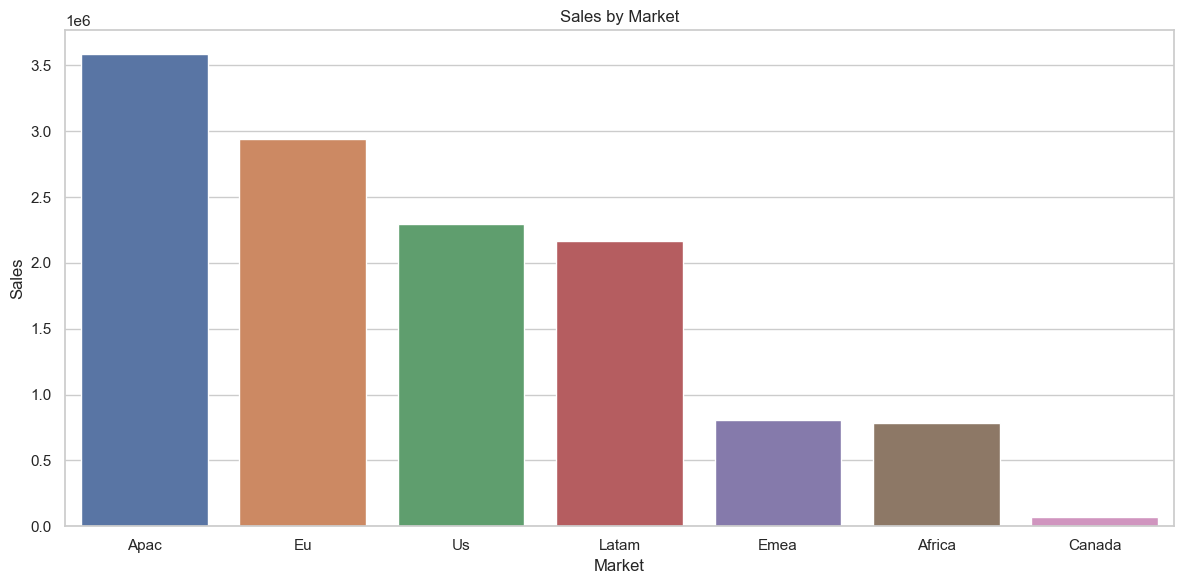

,market,sales,profit,orders,profit_margin
1,Apac,3.585744e+06,436000.04900,5437,0.121593
4,Eu,2.938089e+06,372829.74150,4593,0.126895
6,Us,2.297201e+06,286397.02170,5009,0.124672
5,Latam,2.164605e+06,221643.48708,5138,0.102394
3,Emea,8.061613e+05,43897.97100,2462,0.054453
0,Africa,7.837732e+05,88871.63100,2232,0.113389
2,Canada,6.692817e+04,17817.39000,201,0.266217


In [26]:
market_perf = (
    orders.groupby("market", as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"))
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
    .sort_values("sales", ascending=False)
)

sns.barplot(data=market_perf, x="market", y="sales", hue="market", legend=False)
plt.title("Sales by Market")
plt.xlabel("Market")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

market_perf

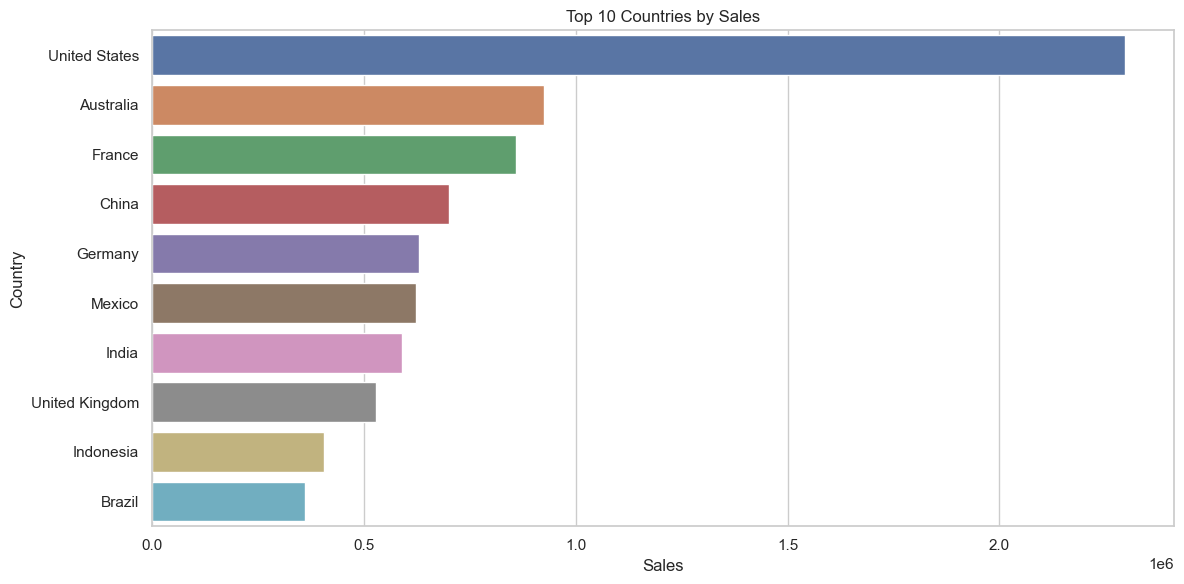

,country,sales,profit
139,United States,2.297201e+06,286397.02170
6,Australia,9.252359e+05,103907.43300
44,France,8.589311e+05,109029.00300
26,China,7.005620e+05,150683.08500
47,Germany,6.288400e+05,107322.82050
81,Mexico,6.225906e+05,102818.09752
57,India,5.896501e+05,129071.83500
138,United Kingdom,5.285763e+05,111900.15000
58,Indonesia,4.048875e+05,15608.67790
17,Brazil,3.611064e+05,30090.49896


In [27]:
top_countries = (
    orders.groupby("country", as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"))
    .sort_values("sales", ascending=False)
    .head(10)
)

sns.barplot(data=top_countries, y="country", x="sales", hue="country", legend=False)
plt.title("Top 10 Countries by Sales")
plt.xlabel("Sales")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

top_countries

**Insight:** Market and country performance highlights where the business should prioritize expansion, retention, and operational support.

## 9. Customer Segment Analysis

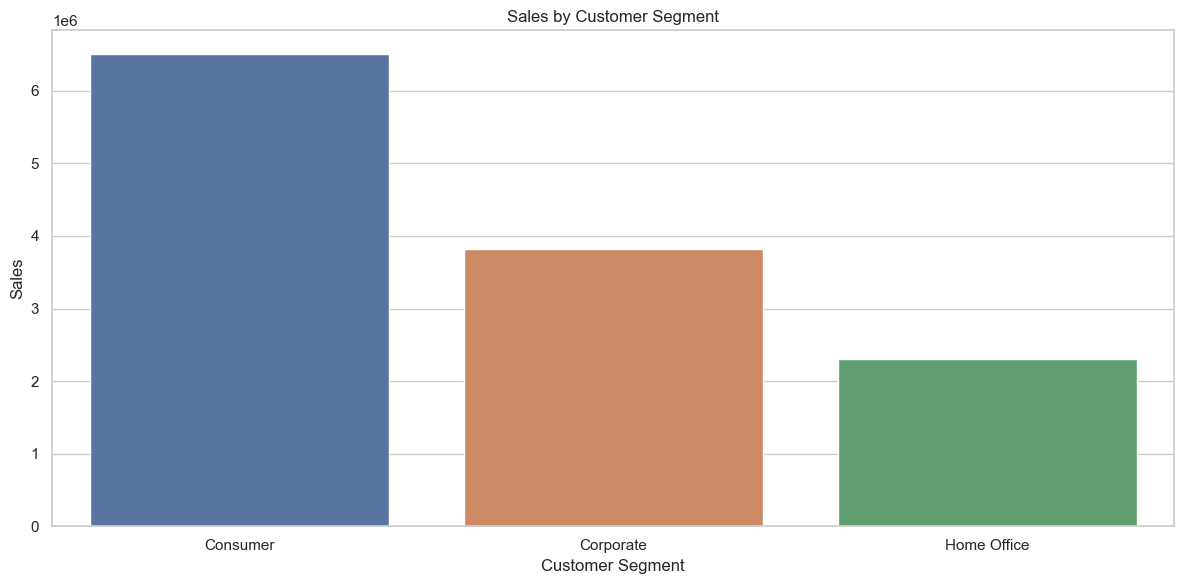

,customer_segment,customers,orders,sales,profit,profit_margin
0,Consumer,818,13104,6.507949e+06,749239.78206,0.115127
1,Corporate,476,7673,3.824698e+06,441208.32866,0.115358
2,Home Office,296,4687,2.309855e+06,277009.18056,0.119925


In [28]:
segment_perf = (
    orders.groupby("customer_segment", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        orders=("order_id", "nunique"),
        sales=("sales", "sum"),
        profit=("profit", "sum")
    )
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
    .sort_values("sales", ascending=False)
)

sns.barplot(data=segment_perf, x="customer_segment", y="sales", hue="customer_segment", legend=False)
plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

segment_perf

**Insight:** Segment analysis shows which customer groups are most valuable and where targeted campaigns may improve revenue or margin.

## 10. Sales Bucket Analysis

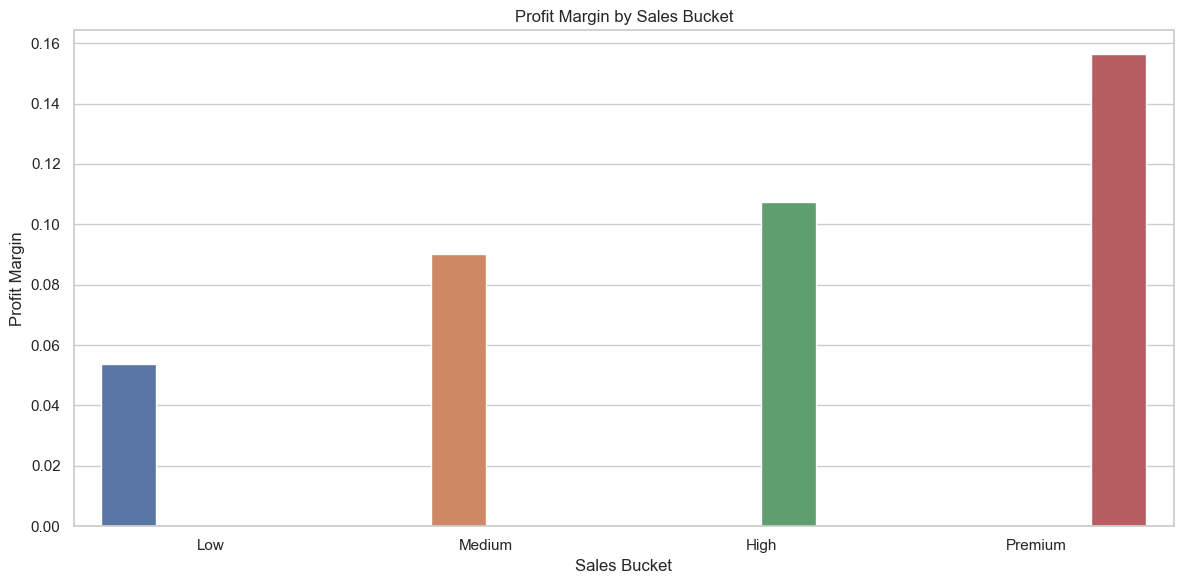

,sales_bucket,line_items,sales,profit,profit_margin
0,Low,27843,1.102546e+06,59137.15790,0.053637
1,Medium,16695,3.859717e+06,348469.25754,0.090284
2,High,4126,2.876502e+06,308522.53604,0.107256
3,Premium,2626,4.803737e+06,751328.33980,0.156405


In [29]:
sales_bucket_perf = (
    orders.groupby("sales_bucket", observed=False, as_index=False)
    .agg(line_items=("order_id", "count"), sales=("sales", "sum"), profit=("profit", "sum"))
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
)

sns.barplot(data=sales_bucket_perf, x="sales_bucket", y="profit_margin", hue="sales_bucket", legend=False)
plt.title("Profit Margin by Sales Bucket")
plt.xlabel("Sales Bucket")
plt.ylabel("Profit Margin")
plt.tight_layout()
plt.show()

sales_bucket_perf

**Insight:** Sales buckets help compare smaller transactions with high-value orders and show whether larger transactions are also more profitable.

## 11. Discount Impact on Profitability

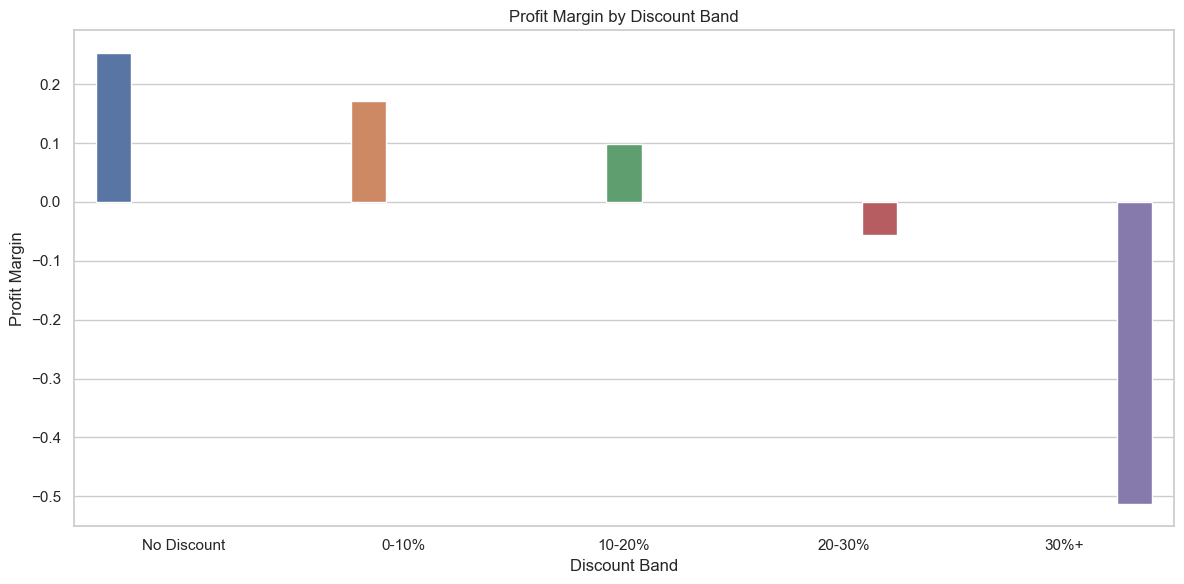

,discount_band,line_items,sales,profit,profit_margin
0,No Discount,29009,6.992411e+06,1.770695e+06,0.253231
1,0-10%,4679,1.962619e+06,3.381893e+05,0.172315
2,10-20%,6274,1.757261e+06,1.732548e+05,0.098594
3,20-30%,967,3.825547e+05,-2.115561e+04,-0.055301
4,30%+,10361,1.547656e+06,-7.935265e+05,-0.512728


In [30]:
discount_perf = (
    orders.groupby("discount_band", observed=False, as_index=False)
    .agg(line_items=("order_id", "count"), sales=("sales", "sum"), profit=("profit", "sum"))
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
)

sns.barplot(data=discount_perf, x="discount_band", y="profit_margin", hue="discount_band", legend=False)
plt.title("Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin")
plt.tight_layout()
plt.show()

discount_perf

**Insight:** Discount bands reveal whether higher discounts are helping sales or damaging profitability. This supports a more controlled promotional strategy.

## 12. Shipping and Return Analysis

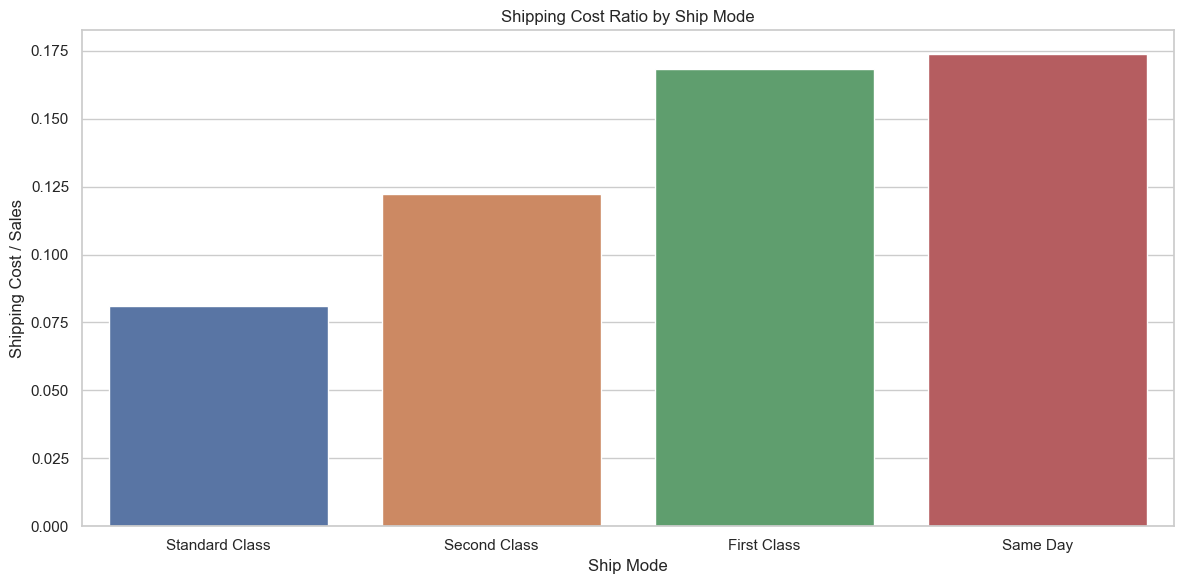

,ship_mode,orders,sales,shipping_cost,avg_shipping_delay,shipping_cost_ratio
3,Standard Class,15154,7.578652e+06,614627.65550,4.998018,0.081100
2,Second Class,5119,2.565672e+06,314111.79036,3.230187,0.122429
0,First Class,3821,1.830976e+06,308102.54154,2.181746,0.168272
1,Same Day,1347,6.672020e+05,115973.71600,0.037394,0.173821


In [31]:
ship_perf = (
    orders.groupby("ship_mode", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        sales=("sales", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        avg_shipping_delay=("shipping_delay", "mean")
    )
    .assign(shipping_cost_ratio=lambda df: df["shipping_cost"] / df["sales"])
    .sort_values("sales", ascending=False)
)

sns.barplot(data=ship_perf, x="ship_mode", y="shipping_cost_ratio", hue="ship_mode", legend=False)
plt.title("Shipping Cost Ratio by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Shipping Cost / Sales")
plt.tight_layout()
plt.show()

ship_perf

In [32]:
return_by_market = (
    orders.groupby("market", as_index=False)
    .agg(total_orders=("order_id", "nunique"), returned_orders=("is_returned", "sum"))
    .assign(return_rate=lambda df: df["returned_orders"] / df["total_orders"])
    .sort_values("return_rate", ascending=False)
)

return_by_market

,market,total_orders,returned_orders,return_rate
5,Latam,5138,825,0.160568
6,Us,5009,802,0.160112
1,Apac,5437,786,0.144565
4,Eu,4593,637,0.138689
0,Africa,2232,0,0.000000
2,Canada,201,0,0.000000
3,Emea,2462,0,0.000000


**Insight:** Shipping mode and return-rate analysis can help identify operational areas that affect customer satisfaction and margin.

## 13. Final Business Recommendations

- Prioritize high-sales markets while monitoring profit margin, not just revenue.
- Review sub-categories with high sales but weak or negative profit.
- Set discount guardrails for products and regions where discounts reduce margin.
- Track returns by market and category to identify quality or fulfillment issues.
- Use customer segment performance to design targeted marketing and retention campaigns.
- Combine growth goals with profit-margin guardrails so expansion improves both revenue and business value.